In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import warnings, os, platform

# 환경 설정
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# 판다스 출력 설정 (표를 더 잘 보기 위함)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 2000)

# -------------------------------------------------
# 한글 폰트 (맥북용)
# -------------------------------------------------
# 한글 폰트 설정 (맥북용 최적화)
def set_korean_font():
    # 맥용 한글 폰트 후보들
    candidates = [
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/Library/Fonts/Arial Unicode.ttf",
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
    ]
    
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False # 마이너스 기호 깨짐 방지
            return font_name
    
    # 폰트를 못 찾았을 경우 기본값
    plt.rcParams["font.family"] = "DejaVu Sans"
    return "DejaVu Sans"

# 실행 및 결과 확인
FONT = set_korean_font()
print(f"사용 폰트: {FONT}")

# -------------------------------------------------
# 경로
# -------------------------------------------------
DATA_DIR = "/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw"

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\n컬럼 명 확인")
print(train.columns.tolist())

display(train.head())

사용 폰트: Apple SD Gothic Neo
Train shape: (256351, 69)
Test shape : (90067, 68)

컬럼 명 확인
['ID', '시술 시기 코드', '시술 당시 나이', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,부부 부 불임 원인,불명확 불임 원인,불임 원인 - 난관 질환,불임 원인 - 남성 요인,불임 원인 - 배란 장애,불임 원인 - 여성 요인,불임 원인 - 자궁경부 문제,불임 원인 - 자궁내막증,불임 원인 - 정자 농도,불임 원인 - 정자 면역학적 요인,불임 원인 - 정자 운동성,불임 원인 - 정자 형태,배아 생성 주요 이유,총 시술 횟수,클리닉 내 총 시술 횟수,IVF 시술 횟수,DI 시술 횟수,총 임신 횟수,IVF 임신 횟수,DI 임신 횟수,총 출산 횟수,IVF 출산 횟수,DI 출산 횟수,총 생성 배아 수,미세주입된 난자 수,미세주입에서 생성된 배아 수,이식된 배아 수,미세주입 배아 이식 수,저장된 배아 수,미세주입 후 저장된 배아 수,해동된 배아 수,해동 난자 수,수집된 신선 난자 수,저장된 신선 난자 수,혼합된 난자 수,파트너 정자와 혼합된 난자 수,기증자 정자와 혼합된 난자 수,난자 출처,정자 출처,난자 기증자 나이,정자 기증자 나이,동결 배아 사용 여부,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,4.0,5.0,4.0,2.0,2.0,2.0,2.0,0.0,0.0,7.0,0.0,5.0,5.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,현재 시술용,1회,0회,1회,0회,0회,0회,0회,0회,0회,0회,5.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,7.0,7.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,현재 시술용,1회,1회,1회,0회,0회,0회,0회,0회,0회,0회,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,4.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,6.0,6.0,6.0,2.0,2.0,0.0,0.0,0.0,0.0,7.0,0.0,6.0,6.0,0.0,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.0,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [3]:
# -------------------------------------------------
# 컬럼 분류 (수치형 / 범주형 2분류 방식)
# -------------------------------------------------
train_feats = [c for c in train.columns if c not in [TARGET, ID_COL]]

# 수치형: 숫자 타입 + 고유값이 충분히 많은 컬럼
num_cols = [
    c for c in train_feats
    if pd.api.types.is_numeric_dtype(train[c]) and train[c].nunique() > 10
]

# 범주형:
# 1) 문자형(object, category)
# 2) 숫자형이지만 고유값이 적은 코드형 변수(0/1, 횟수코드 등)
cat_cols = [
    c for c in train_feats
    if (not pd.api.types.is_numeric_dtype(train[c])) or (train[c].nunique() <= 10)
]

print("수치형:", len(num_cols))
print("범주형:", len(cat_cols))

print("\n수치형 컬럼")
print(num_cols)

print("\n범주형 컬럼")
print(cat_cols)

수치형: 13
범주형: 54

수치형 컬럼
['임신 시도 또는 마지막 임신 경과 연수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수']

범주형 컬럼
['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '이식된 배아 수', '미세주입 배아 이식 수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']


,컬럼,결측수,결측률(%)
0,난자 해동 경과일,254915,99.44
1,PGS 시술 여부,254422,99.25
2,PGD 시술 여부,254172,99.15
3,착상 전 유전 검사 사용 여부,253633,98.94
4,임신 시도 또는 마지막 임신 경과 연수,246981,96.34
5,배아 해동 경과일,215982,84.25
6,난자 채취 경과일,57488,22.43
7,난자 혼합 경과일,53735,20.96
8,배아 이식 경과일,43566,16.99
9,총 생성 배아 수,6291,2.45


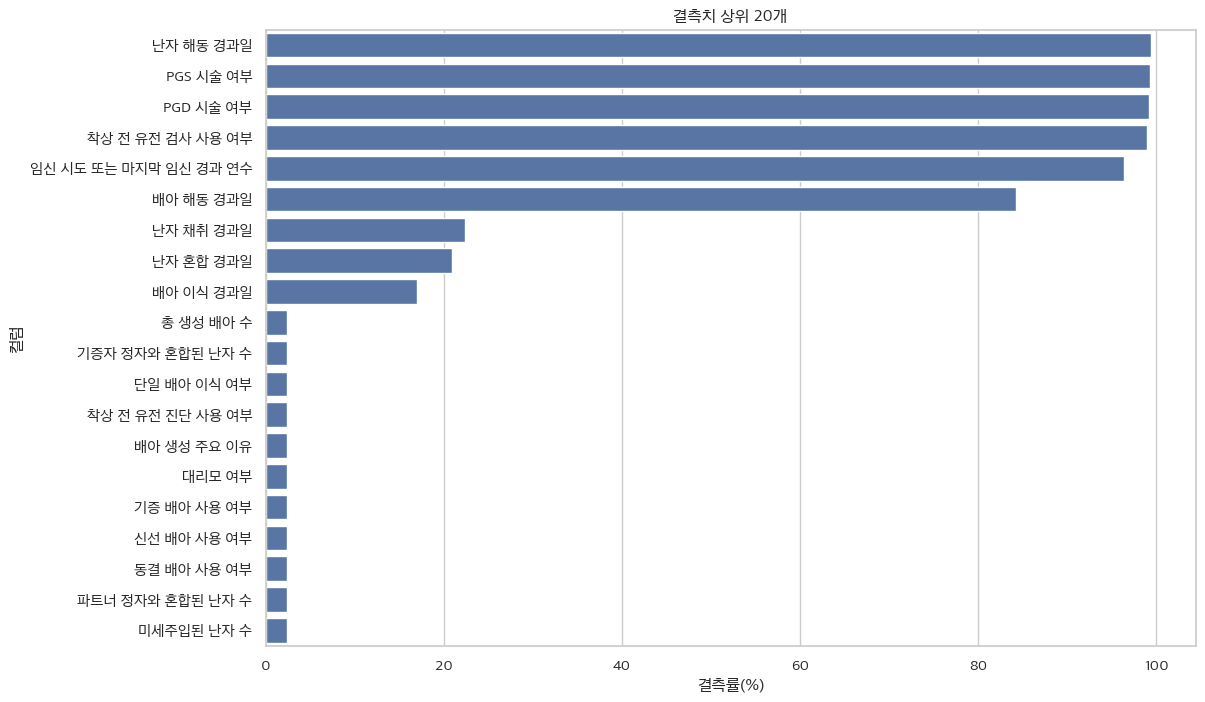

In [4]:
# -------------------------------------------------
# 1. 결측치 분석
# -------------------------------------------------
miss = train.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

miss_df = pd.DataFrame({
    "컬럼": miss.index,
    "결측수": miss.values,
    "결측률(%)": (miss.values / len(train) * 100).round(2)
})

display(miss_df.head(20))

plt.figure(figsize=(12,8))
sns.barplot(data=miss_df.head(20), y="컬럼", x="결측률(%)")
plt.title("결측치 상위 20개")
plt.show()

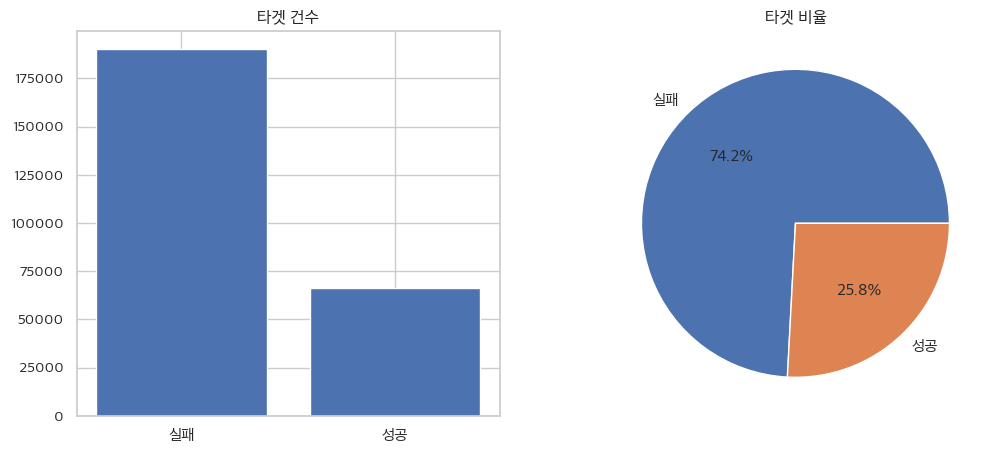

In [5]:
# -------------------------------------------------
# 2. 타겟 분포
# -------------------------------------------------
cnt = train[TARGET].value_counts()

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].bar(["실패","성공"], cnt.values)
axes[0].set_title("타겟 건수")

axes[1].pie(cnt.values, labels=["실패","성공"], autopct="%1.1f%%")
axes[1].set_title("타겟 비율")

plt.show()

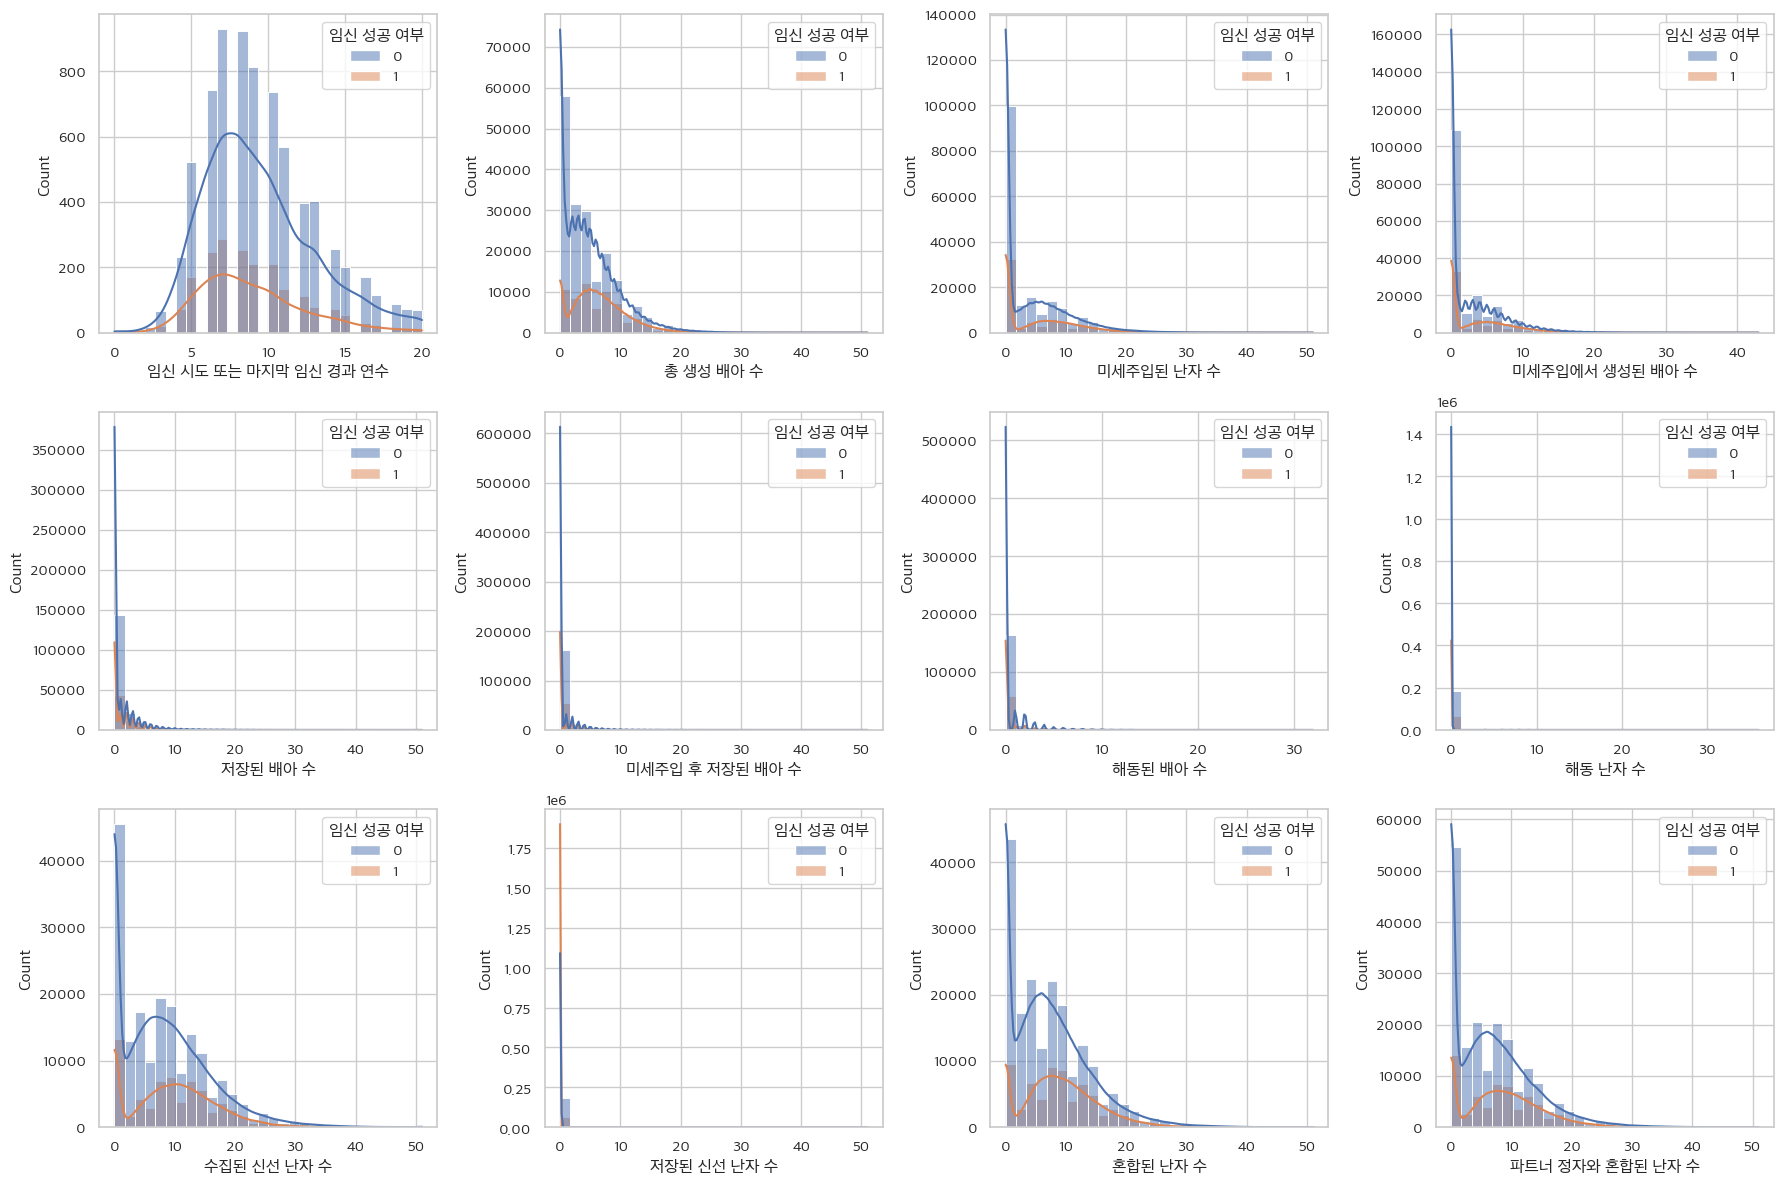

In [6]:
# -------------------------------------------------
# 3. 수치형 변수 분포
# -------------------------------------------------
sample_cols = num_cols[:12]

fig, axes = plt.subplots(3,4, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(sample_cols):
    sns.histplot(data=train, x=col, hue=TARGET, kde=True, ax=axes[i], bins=30)

plt.tight_layout()
plt.show()

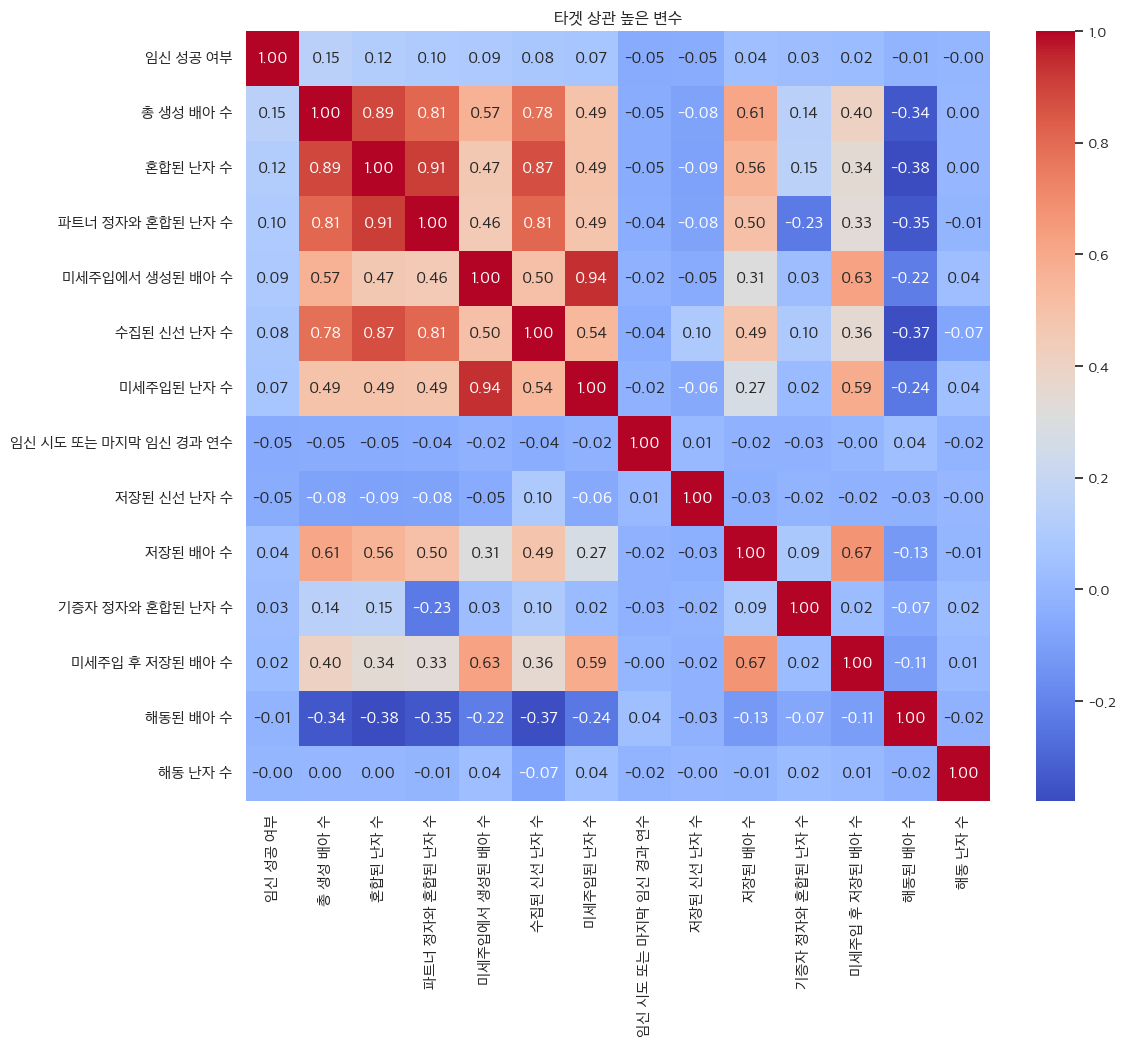

In [7]:
# -------------------------------------------------
# 4. 상관관계 히트맵
# -------------------------------------------------
corr = train[num_cols + [TARGET]].corr()

top = corr[TARGET].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(train[top].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("타겟 상관 높은 변수")
plt.show()

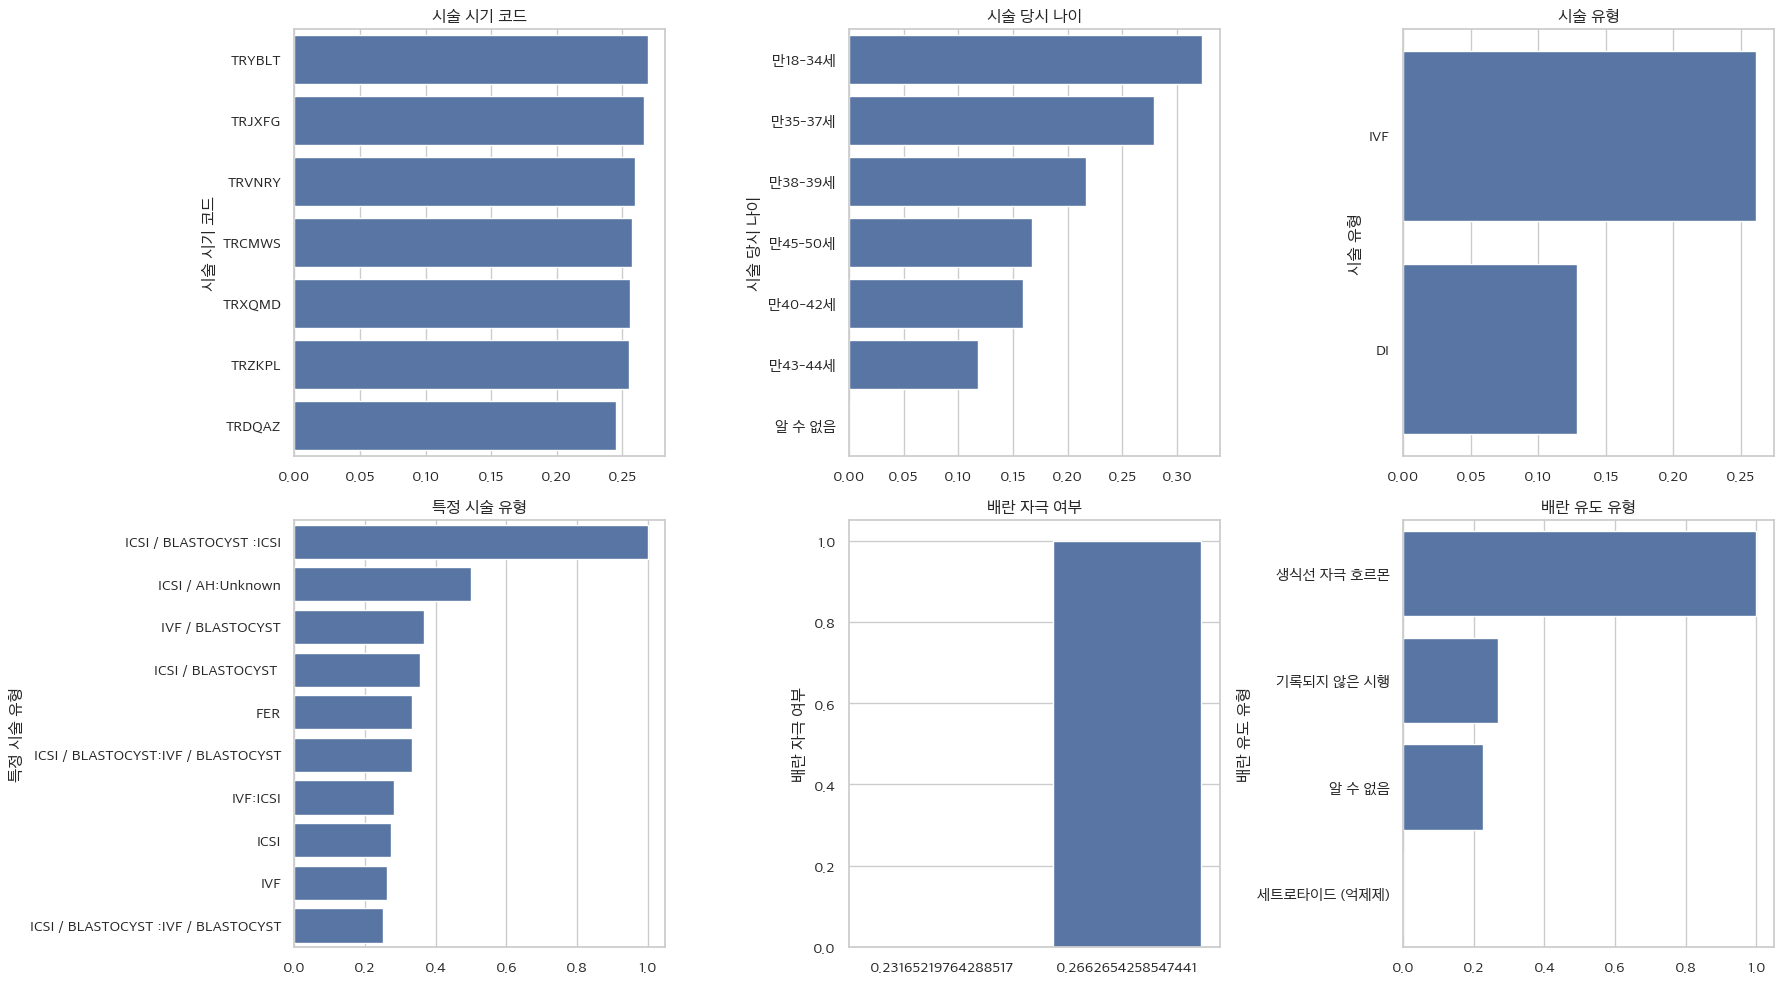

In [8]:
# -------------------------------------------------
# 5. 범주형 성공률
# -------------------------------------------------
important = cat_cols[:6]

fig, axes = plt.subplots(2,3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(important):
    tmp = train.groupby(col)[TARGET].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=tmp.values, y=tmp.index, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [9]:
# -------------------------------------------------
# 6. 요약
# -------------------------------------------------
print("Train:", train.shape)
print("Test :", test.shape)
print()
print("성공률:", round(train[TARGET].mean()*100,2), "%")
print()
print("상관 높은 변수 TOP5")
display(corr[TARGET].abs().sort_values(ascending=False).head(6))

Train: (256351, 69)
Test : (90067, 68)

성공률: 25.83 %

상관 높은 변수 TOP5


임신 성공 여부            1.000000
총 생성 배아 수           0.146116
혼합된 난자 수            0.116136
파트너 정자와 혼합된 난자 수    0.104902
미세주입에서 생성된 배아 수     0.090275
수집된 신선 난자 수         0.083023
Name: 임신 성공 여부, dtype: float64

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool

# 1. 데이터 로드
train = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/train.csv')
test = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/test.csv')

# ID 및 타겟 분리
target = '임신 성공 여부' 
X = train.drop(['ID', target], axis=1)
y = train[target]
X_test = test.drop(['ID'], axis=1)

# 2. 범주형 변수 처리 (CatBoost는 자체 처리가 가능하므로 결측치만 보정)
cat_features = X.select_dtypes(include=['object']).columns.tolist()
X[cat_features] = X[cat_features].fillna('None')
X_test[cat_features] = X_test[cat_features].fillna('None')

# 3. 모델링 및 교차 검증 (ROC-AUC 평가)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=1000,
        eval_metric='AUC',
        random_seed=42,
        verbose=100,
        cat_features=cat_features
    )
    
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

# 4. 최종 평가
score = roc_auc_score(y, oof_preds)
print(f"Overall OOF ROC-AUC Score: {score:.4f}")

Learning rate set to 0.11802
0:	test: 0.6946161	best: 0.6946161 (0)	total: 214ms	remaining: 3m 33s
100:	test: 0.7374410	best: 0.7374410 (100)	total: 15.1s	remaining: 2m 14s
200:	test: 0.7379055	best: 0.7379055 (200)	total: 30.6s	remaining: 2m 1s
300:	test: 0.7381359	best: 0.7381445 (297)	total: 46.2s	remaining: 1m 47s
400:	test: 0.7383959	best: 0.7383993 (399)	total: 1m 1s	remaining: 1m 32s
500:	test: 0.7383782	best: 0.7384469 (419)	total: 1m 16s	remaining: 1m 16s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7384468754
bestIteration = 419

Shrink model to first 420 iterations.
Learning rate set to 0.11802
0:	test: 0.7003449	best: 0.7003449 (0)	total: 199ms	remaining: 3m 18s
100:	test: 0.7414794	best: 0.7414794 (100)	total: 14.1s	remaining: 2m 5s
200:	test: 0.7423684	best: 0.7423684 (200)	total: 29.9s	remaining: 1m 58s
300:	test: 0.7425855	best: 0.7425855 (300)	total: 45.3s	remaining: 1m 45s
400:	test: 0.7425057	best: 0.7425855 (300)	total: 1m	remaining: 1m 30s
S

In [13]:
submission = pd.read_csv("/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/sample_submission.csv")

print(submission.columns)

submission.iloc[:, 1] = test_preds  

submission.to_csv("submission.csv", index=False, encoding="utf-8")

display(submission.head())

Index(['ID', 'probability'], dtype='str')


,ID,probability
0,TEST_00000,0.001947
1,TEST_00001,0.009288
2,TEST_00002,0.151741
3,TEST_00003,0.109085
4,TEST_00004,0.493528
